In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [25]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"

latent_df = pd.read_parquet(DATA_LATENT / "fc_vae_latents.parquet")

latent_df.head()

,date,ticker,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.619362,-0.291282,1.218507,-1.537995,-0.378683,-0.759858,0.066653,-0.840747
1,2015-09-22,AAPL,-0.727026,-0.177698,1.383948,-1.456320,-0.351501,-0.799361,-0.037340,-0.873263
2,2015-09-23,AAPL,-0.811343,-0.079573,1.356158,-1.388889,-0.337329,-0.717278,-0.089436,-0.947264
3,2015-09-24,AAPL,-0.956392,0.021238,1.388825,-1.334907,-0.281220,-0.718173,-0.138247,-0.959101
4,2015-09-25,AAPL,-1.019286,0.120451,1.327576,-1.271330,-0.350556,-0.711358,-0.211038,-0.988253


In [26]:
z_cols = [c for c in latent_df.columns if c.startswith("z_")]

Z = latent_df[z_cols].values

Z.shape

(70080, 8)

In [27]:
latent_df["date"] = pd.to_datetime(latent_df["date"])

print("date range:", latent_df["date"].min(), "->", latent_df["date"].max())
print("n samples:", len(latent_df))
print("n tickers:", latent_df["ticker"].nunique())
print("latent dim:", len(z_cols))

date range: 2015-09-21 00:00:00 -> 2024-12-31 00:00:00
n samples: 70080
n tickers: 30
latent dim: 8


In [28]:
latent_df[z_cols].describe()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
count,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000
mean,0.010021,-0.022339,0.014566,-0.010368,-0.001552,-0.193949,0.063383,0.006475
std,0.989352,1.013165,1.034185,1.082003,1.030956,1.092491,1.038564,1.035202
min,-7.912680,-9.369986,-6.615457,-6.550128,-8.866323,-2.537567,-6.609138,-10.339501
25%,-0.553115,-0.580939,-0.619587,-0.616697,-0.589724,-0.947138,-0.525059,-0.556414
50%,0.019821,-0.029670,-0.066890,0.004031,-0.023486,-0.367969,0.137905,0.061881
75%,0.591618,0.552331,0.525969,0.585209,0.580782,0.363757,0.743796,0.646533
max,7.887802,5.608112,8.938188,8.916887,6.343338,7.659924,7.796960,6.954545


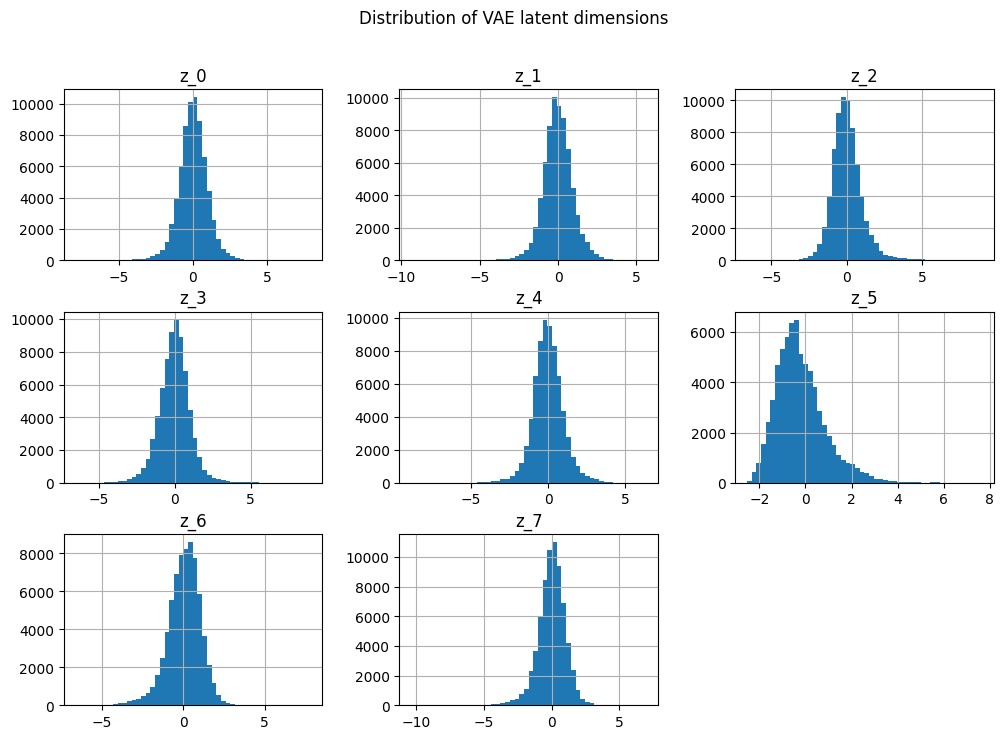

In [29]:
latent_df[z_cols].hist(
    bins=50,
    figsize=(12, 8)
)

plt.suptitle("Distribution of VAE latent dimensions")
plt.show()

In [30]:
pca = PCA(n_components=2)

Z_pca = pca.fit_transform(Z)

latent_df["pc1"] = Z_pca[:, 0]
latent_df["pc2"] = Z_pca[:, 1]

pca.explained_variance_ratio_

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


array([0.18370745, 0.15767255], dtype=float32)

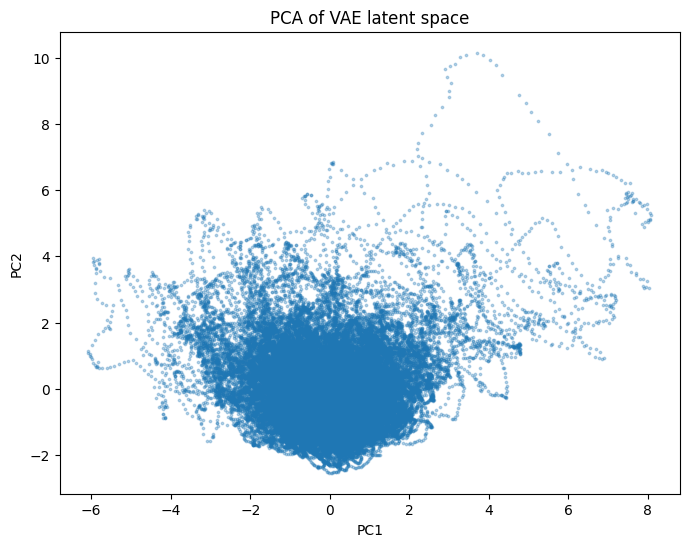

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    s=3,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of VAE latent space")
plt.show()

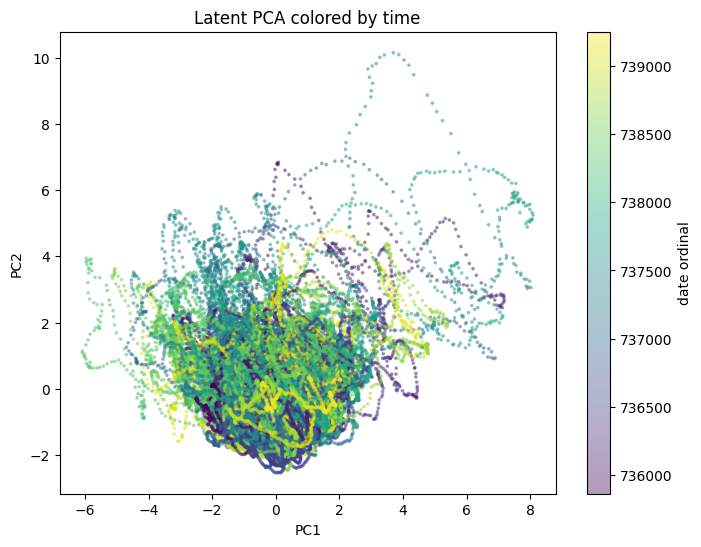

In [32]:
date_numeric = latent_df["date"].map(pd.Timestamp.toordinal)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    c=date_numeric,
    s=3,
    alpha=0.4
)

plt.colorbar(sc, label="date ordinal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent PCA colored by time")
plt.show()

In [33]:
ticker_latent_mean = (
    latent_df
    .groupby("ticker")[z_cols]
    .mean()
)

ticker_latent_mean.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
ticker,,,,,,,,
AAPL,-0.004273,-0.063787,-0.016590,0.110131,0.069203,-0.222308,0.119262,0.046603
ABBV,0.034702,0.038316,-0.039162,-0.048334,0.013306,-0.484742,0.151905,0.076599
ADBE,0.020479,-0.039558,0.039273,-0.006236,0.034131,0.078575,-0.030995,-0.075989
AMD,-0.100332,-0.250139,0.450627,0.276682,0.059968,1.868273,-0.345096,-0.411923
AMZN,-0.012257,-0.085861,0.054991,0.045679,0.055446,0.082039,0.006883,-0.072649


In [34]:
ticker_pca = PCA(n_components=2)
ticker_Z_pca = ticker_pca.fit_transform(ticker_latent_mean.values)

ticker_latent_plot = pd.DataFrame(
    ticker_Z_pca,
    index=ticker_latent_mean.index,
    columns=["pc1", "pc2"]
)

ticker_latent_plot.head()

,pc1,pc2
ticker,,
AAPL,-0.026555,0.140809
ABBV,-0.322273,-0.004977
ADBE,0.295665,-0.041405
AMD,2.218977,-0.011798
AMZN,0.308220,0.036443


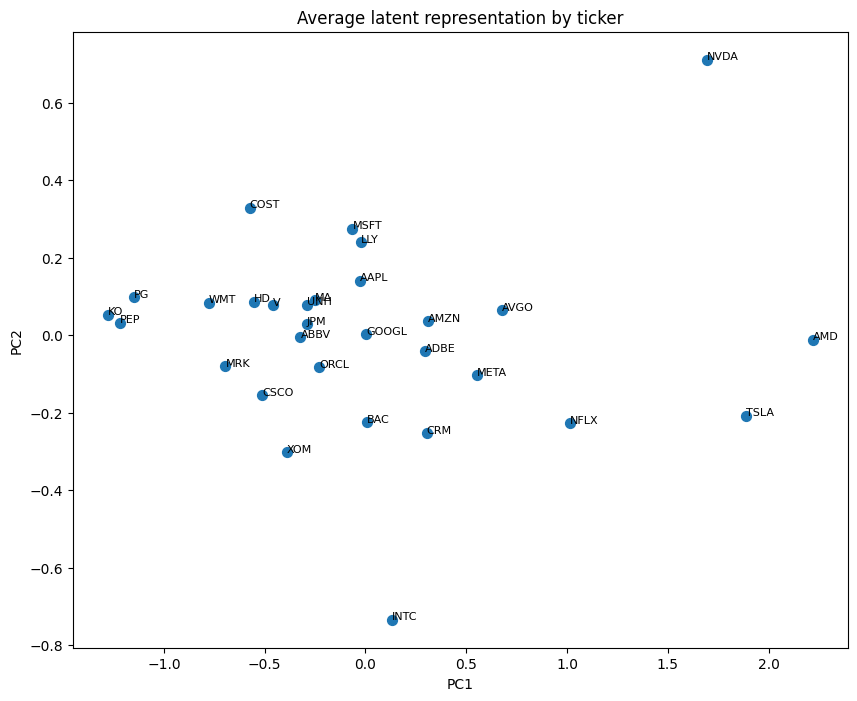

In [35]:
plt.figure(figsize=(10, 8))

plt.scatter(
    ticker_latent_plot["pc1"],
    ticker_latent_plot["pc2"],
    s=50
)

for ticker, row in ticker_latent_plot.iterrows():
    plt.text(row["pc1"], row["pc2"], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Average latent representation by ticker")
plt.show()

In [36]:
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init="auto"
)

latent_df["cluster"] = kmeans.fit_predict(Z)

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Runt

In [37]:
latent_df["cluster"].value_counts().sort_index()

cluster
0    34428
1    16507
2     5324
3    13821
Name: count, dtype: int64

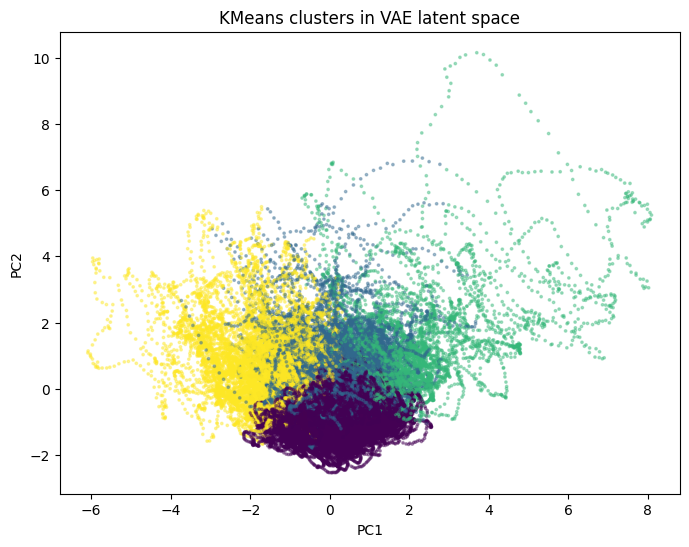

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    c=latent_df["cluster"],
    s=3,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters in VAE latent space")
plt.show()

In [40]:
cluster_by_date = (
    latent_df
    .groupby(["date", "cluster"])
    .size()
    .unstack(fill_value=0)
)

cluster_share_by_date = cluster_by_date.div(
    cluster_by_date.sum(axis=1),
    axis=0
)

cluster_share_by_date.head()

cluster,0,1,2,3
date,,,,
2015-09-21,0.266667,0.533333,0.1,0.100000
2015-09-22,0.233333,0.566667,0.1,0.100000
2015-09-23,0.233333,0.566667,0.1,0.100000
2015-09-24,0.233333,0.566667,0.1,0.100000
2015-09-25,0.233333,0.533333,0.1,0.133333


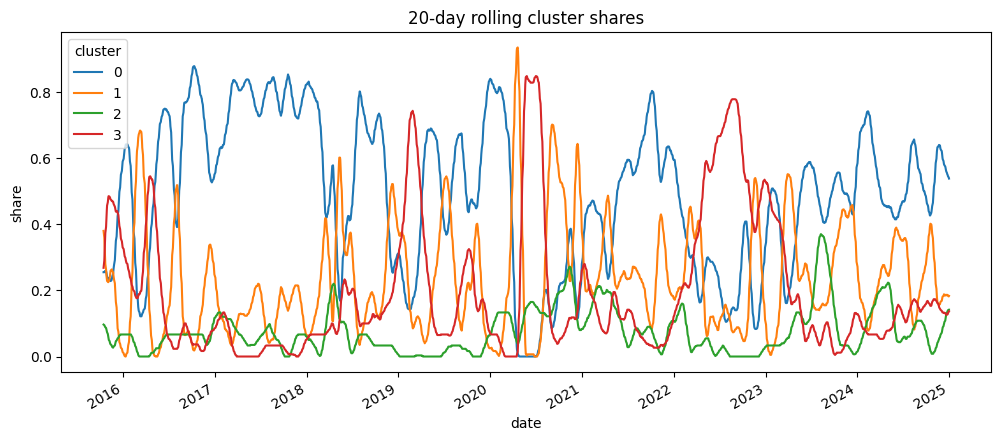

In [41]:
cluster_share_by_date.rolling(20).mean().plot(
    figsize=(12, 5),
    title="20-day rolling cluster shares"
)

plt.ylabel("share")
plt.show()

In [42]:
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
returns.index = pd.to_datetime(returns.index)

returns.head()

Ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.018819,-0.004976,-0.003745,-0.020517,-0.015986,-0.029050,-0.011370,-0.018062,-0.019921,...,-0.050897,-0.016891,-0.014024,-0.007518,-0.004754,-0.042041,-0.016472,-0.022074,-0.002911,-0.027362
2015-01-06,0.000094,-0.004950,-0.020145,-0.011278,-0.022833,-0.022743,-0.029919,0.013214,-0.016675,-0.000370,...,-0.017121,-0.030318,-0.010324,-0.007575,-0.004555,0.005664,-0.002018,-0.006444,0.007706,-0.005316
2015-01-07,0.014022,0.040416,0.008223,-0.019011,0.010600,0.027013,0.004745,0.017413,-0.004720,0.009242,...,0.005192,-0.002606,0.000232,0.029242,0.005245,-0.001562,0.010210,0.013398,0.026532,0.010133
2015-01-08,0.038422,0.010459,0.025453,0.011628,0.006836,0.049974,0.020661,0.008592,0.029159,0.007692,...,0.022188,0.037618,0.006026,0.018174,0.011436,-0.001564,0.047733,0.013412,0.021106,0.016645
2015-01-09,0.001073,-0.027355,-0.014811,0.007663,-0.011749,0.010695,-0.017930,-0.015389,-0.007339,0.010179,...,-0.015458,0.004028,-0.000461,-0.006771,-0.009331,-0.018802,-0.009360,-0.014823,-0.012380,-0.001409


In [43]:
returns_next = returns.shift(-1)

future_return_list = []

for _, row in latent_df[["date", "ticker"]].iterrows():
    date = row["date"]
    ticker = row["ticker"]

    try:
        future_return_list.append(returns_next.loc[date, ticker])
    except KeyError:
        future_return_list.append(np.nan)

latent_df["future_return_1d"] = future_return_list

latent_df = latent_df.dropna(subset=["future_return_1d"])

In [44]:
cluster_return_stats = (
    latent_df
    .groupby("cluster")["future_return_1d"]
    .agg(["mean", "std", "count"])
)

cluster_return_stats["sharpe_like"] = (
    cluster_return_stats["mean"] / cluster_return_stats["std"]
)

cluster_return_stats

,mean,std,count,sharpe_like
cluster,,,,
0,0.000650,0.014853,34412,0.043768
1,0.001311,0.022215,16501,0.059022
2,0.001941,0.030475,5321,0.063701
3,0.001136,0.024980,13816,0.045466


In [45]:
corrs = {}

for col in z_cols:
    corrs[col] = latent_df[col].corr(latent_df["future_return_1d"])

corrs = pd.Series(corrs).sort_values()

corrs

z_7   -0.016861
z_3   -0.008558
z_1   -0.008387
z_0   -0.002618
z_4   -0.000193
z_2    0.002625
z_6    0.005285
z_5    0.026278
dtype: float64

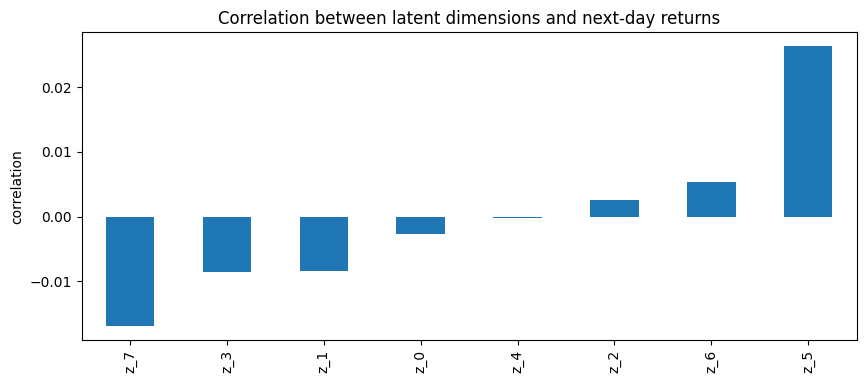

In [46]:
corrs.plot(
    kind="bar",
    figsize=(10, 4),
    title="Correlation between latent dimensions and next-day returns"
)

plt.ylabel("correlation")
plt.show()

In [23]:
latent_df.to_parquet(DATA_LATENT / "fc_vae_latents_analyzed.parquet")